In [8]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import ndcg_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRanker
import lightgbm as lgb
from visualization import plot_xgbranker, plot_triage
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# Supervised Learning-to-Rank (Pairwise Architecture)

## The Calculus of Pairwise Gradient Boosting (LambdaRank)

To deduce the optimal "Next-Best-Action" within a student's pending task queue, standard transductive classification is structurally invalid, as it evaluates documents in a vacuum. The problem is instead formulated via a Pairwise Learning-to-Rank (LTR) paradigm, utilizing the **LambdaMART** algorithmic architecture.

While standard gradient boosting minimizes differentiable pointwise errors (e.g., Mean Squared Error), Information Retrieval metrics like $\text{NDCG}$ rely on sorting operations, which are mathematically non-differentiable. To optimize the ensemble, the architecture utilizes the **LambdaRank** heuristic to compute empirical, sequence-aware gradients.

For any pair of documents $(d_i, d_j)$ within a specific user's query session $q$, where document $i$ is empirically more urgent than document $j$ ($y_i > y_j$), the modeled probability $P_{ij}$ that $i$ outranks $j$ is derived via a logistic sigmoid applied to the difference in their latent utility scores $(s_i - s_j)$:

$$
P_{ij} = \frac{1}{1 + e^{-\sigma(s_i - s_j)}}
$$

The baseline pairwise cross-entropy loss $C$ for this permutation is defined as:

$$
C_{ij} = - \bar{P}_{ij} \log P_{ij} - (1 - \bar{P}_{ij}) \log(1 - P_{ij})
$$

**The Lambda Gradient ($\lambda_{ij}$):**
The mathematical breakthrough of the pairwise architecture is the scaling of this gradient by the absolute change in the Information Retrieval metric ($|\Delta \text{NDCG}|$) that results from swapping the ranks of $i$ and $j$. The gradient (the "lambda" force) pushing the urgent task $i$ up the queue and task $j$ down is formulated as:

$$
\lambda_{ij} = \frac{\partial C_{ij}}{\partial s_i} = \frac{-\sigma}{1 + e^{\sigma(s_i - s_j)}} |\Delta \text{NDCG}_{ij}|
$$

By weighting the gradient update by $|\Delta \text{NDCG}_{ij}|$, the second-order Taylor expansion utilized by XGBoost prioritizes fixing inversion errors at the top of the queue (e.g., Rank 1 vs Rank 2) significantly more than errors at the bottom (e.g., Rank 9 vs Rank 10). This perfectly aligns the mathematical optimizer with the spatial constraints of a mobile interface, ensuring the single most critical task is forced to the top of the viewport.

In [9]:
print("[*] Initializing Engine 3: Pairwise Learning-to-Rank Architecture...")
print("[*] Executing Stochastic DGP with Structural `qid` Constraints...")
np.random.seed(42)
M_sessions = 1000
stochastic_records = []

for qid in range(1, M_sessions + 1):
    N_tasks = np.random.randint(4, 15) 
    session_burnout_rho = np.random.uniform(1.0, 10.0)
    
    delta_t_due = np.random.exponential(scale=48.0, size=N_tasks)
    psi_complexity = np.random.randint(1, 6, size=N_tasks)
    v_hist_velocity = np.random.normal(loc=45.0, scale=15.0, size=N_tasks)
    
    latent_utility = -delta_t_due - (psi_complexity * session_burnout_rho * 0.6) - (v_hist_velocity * 0.1)
    optimal_idx = np.argmax(latent_utility)
    
    for i in range(N_tasks):
        stochastic_records.append({
            'qid': qid,
            'time_to_due_date': np.clip(delta_t_due[i], 1.0, 336.0),
            'dynamic_difficulty': psi_complexity[i],
            'user_burnout_index': session_burnout_rho,
            'historical_velocity_for_tag': np.clip(v_hist_velocity[i], 5.0, 180.0),
            'interaction_label': 1 if i == optimal_idx else 0
        })

df_rank = pd.DataFrame(stochastic_records)
df_rank = df_rank.sort_values(by=['qid']).reset_index(drop=True)

print(f"[+] LTR Manifold compiled. Total Operations Matrix: {df_rank.shape}")
print(f"[+] Structural Query Groups Extracted: {df_rank['qid'].nunique()}")
print(f"[+] Sparsity Proof: Mean interactions per query group = {df_rank.groupby('qid')['interaction_label'].sum().mean():.1f}")

[*] Initializing Engine 3: Pairwise Learning-to-Rank Architecture...
[*] Executing Stochastic DGP with Structural `qid` Constraints...
[+] LTR Manifold compiled. Total Operations Matrix: (8983, 6)
[+] Structural Query Groups Extracted: 1000
[+] Sparsity Proof: Mean interactions per query group = 1.0


## Information Retrieval Protocol & Topological Splitting

Standard classification paradigms evaluate predictive success via a global confusion matrix. In contrast, Information Retrieval (IR) architectures are evaluated strictly on their local ranking permutations. The penalty for a false negative is non-linear; failing to identify the optimal task ($Y=1$) is penalized substantially more if the task is pushed to rank 10 versus rank 2.

**Normalized Discounted Cumulative Gain (NDCG_k)**
To quantify this, the pipeline utilizes $\text{NDCG}_k$, which measures the ranking quality of the top $k$ retrieved documents within a specific query session $q$. 

The Discounted Cumulative Gain is defined as:

$$
\text{DCG}_k = \sum_{i=1}^{k} \frac{2^{rel_i} - 1}{\log_2(i + 1)}
$$

Where $rel_i \in \{0, 1\}$ represents the ground-truth relevance of the document at rank $i$.

Because backlog sizes vary per session (e.g., $N=5$ vs $N=15$), the raw $\text{DCG}_k$ is normalized against the Ideal DCG ($\text{IDCG}_k$), ensuring the metric remains bound between $[0.0, 1.0]$:

$$
\text{NDCG}_k = \frac{\text{DCG}_k}{\text{IDCG}_k}
$$

**Topological Splitting (Group Shuffle Split)**
Randomized $k$-fold cross-validation or standard `train_test_split` introduces catastrophic data leakage in LTR pipelines. If tasks from the same query session $q_{100}$ are partitioned across both the training and testing sets, the algorithm's pairwise logic fractures. The manifold is therefore partitioned utilizing a **Group Shuffle Split**, ensuring that all documents belonging to a specific `qid` remain mathematically isolated within either the training or testing manifold.

In [10]:
print("[*] Initiating Pairwise Gladiator Arena...")
print("[*] Enforcing Topological Group Shuffle Split (80/20)...\n")
X_features = ['time_to_due_date', 'dynamic_difficulty', 'user_burnout_index', 'historical_velocity_for_tag']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df_rank, groups=df_rank['qid']))
df_train = df_rank.iloc[train_idx].sort_values('qid').reset_index(drop=True)
df_test = df_rank.iloc[test_idx].sort_values('qid').reset_index(drop=True)

X_train, y_train, qid_train = df_train[X_features], df_train['interaction_label'], df_train['qid']
X_test, y_test, qid_test = df_test[X_features], df_test['interaction_label'], df_test['qid']
group_train_counts = df_train.groupby('qid').size().values

def evaluate_ndcg(model, X_t, y_t, qid_t, k=3):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_t)[:, 1]
    else:
        scores = model.predict(X_t)
    df_eval = pd.DataFrame({'qid': qid_t, 'y_true': y_t, 'y_score': scores})
    
    ndcg_scores = []
    for q, group in df_eval.groupby('qid'):
        if group['y_true'].sum() == 0:
            continue
        true_arr = np.asarray([group['y_true'].values])
        score_arr = np.asarray([group['y_score'].values])
        score = ndcg_score(true_arr, score_arr, k=k)
        ndcg_scores.append(score)
        
    return np.mean(ndcg_scores)

architectures = {
    'Logistic Regression (Pointwise)': LogisticRegression(random_state=42),
    'Random Forest (Pointwise)': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBRanker (Pairwise)': XGBRanker(objective='rank:pairwise', random_state=42, eval_metric='ndcg'),
    'LightGBM (LambdaMART)': lgb.LGBMRanker(objective='lambdarank', metric='ndcg', random_state=42, verbose=-1)
}

results_ledger = {}

for name, model in architectures.items():
    if 'XGBRanker' in name:
        model.fit(X_train, y_train, qid=qid_train)
    elif 'LightGBM' in name:
        model.fit(X_train, y_train, group=group_train_counts)
    else:
        model.fit(X_train, y_train)
        
    mean_ndcg = evaluate_ndcg(model, X_test, y_test, qid_test, k=3)
    results_ledger[name] = mean_ndcg
    print(f"    -> {name.ljust(32)} Mean NDCG@3 = {mean_ndcg:.4f}")

champion_algo = max(results_ledger, key=results_ledger.get)
print("\n===================================================================")
print(f"[!] LTR SELECTION COMPILED: {champion_algo} maximizes topological ranking.")
print("===================================================================")

[*] Initiating Pairwise Gladiator Arena...
[*] Enforcing Topological Group Shuffle Split (80/20)...
    -> Logistic Regression (Pointwise)  Mean NDCG@3 = 0.9580
    -> Random Forest (Pointwise)        Mean NDCG@3 = 0.8947
    -> XGBRanker (Pairwise)             Mean NDCG@3 = 0.9673
    -> LightGBM (LambdaMART)            Mean NDCG@3 = 0.9587

[!] LTR SELECTION COMPILED: XGBRanker (Pairwise) maximizes topological ranking.


## Algorithmic Interpretability: Pairwise Feature Contribution

With the `XGBRanker` established as the structural champion, it is imperative to deconstruct its internal decision-making heuristic. Unlike transductive classifiers that evaluate feature importance based on Gini impurity reduction across absolute classes, the pairwise gradient booster evaluates feature contribution based on **Information Gain** during sequence permutation.

The Information Gain $G_j$ for a specific feature $j$ quantifies the average improvement in the pairwise loss function when $j$ is utilized as a splitting criterion across the ensemble of regression trees. High gain indicates that the feature is a primary mathematical driver in determining the relative urgency between two competing tasks $(d_{q,i}, d_{q,j})$.

[*] Deconstructing Pairwise Feature Importance (Information Gain)...


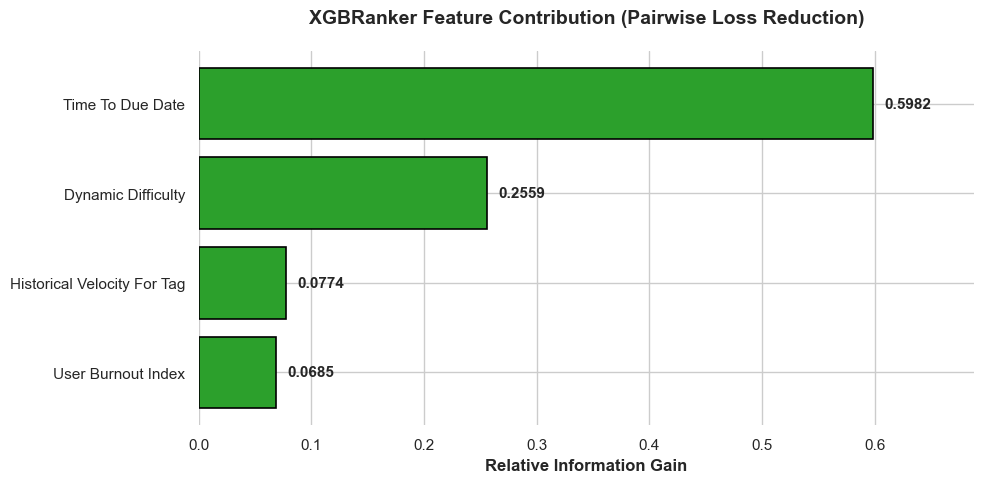

In [11]:
print("[*] Deconstructing Pairwise Feature Importance (Information Gain)...")
champion_model = architectures['XGBRanker (Pairwise)']

importance_scores = champion_model.feature_importances_
feature_names = X_train.columns

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Information Gain': importance_scores
}).sort_values(by='Information Gain', ascending=True)
df_importance['Feature'] = df_importance['Feature'].apply(lambda x: x.replace('_', ' ').title())

plot_xgbranker(df_importance)

## Bayesian Topological Optimization (Tree-Structured Parzen Estimators)

While the baseline `XGBRanker` achieves high empirical performance, the default hyperparameter topology is rarely optimal for specialized Information Retrieval manifolds. To maximize sequence accuracy, the architecture is subjected to Bayesian Optimization utilizing Tree-Structured Parzen Estimators (TPE).

The optimization engine traverses a highly constrained, multi-dimensional parameter space:
* **Learning Rate** ($\eta$): Step size shrinkage utilized in update configurations to prevent overfitting.
* **Max Depth**: The maximum depth of a discrete tree, governing the complexity of interaction effects (e.g., compounding $\Delta t_{due}$ with $\rho$).
* **Gamma** ($\gamma$): The minimum loss reduction required to execute a further partition on a leaf node.

To preserve the integrity of the pairwise loss function during optimization, the cross-validation protocol must rigorously maintain `qid` isolation. A standard $K$-fold split would fracture the temporal sessions. Therefore, the TPE algorithm is mathematically directed to minimize the negative $\text{NDCG}_3$ over a topologically isolated, group-shuffled validation manifold.

In [12]:
print("[*] Initializing Bayesian LTR Optimization Engine...")

def optimize_pairwise_ranker(X_tr, y_tr, qid_tr, max_evals=20):
    gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    idx_t, idx_v = next(gss_val.split(X_tr, groups=qid_tr))
    
    X_t_inner, y_t_inner, qid_t_inner = X_tr.iloc[idx_t], y_tr.iloc[idx_t], qid_tr.iloc[idx_t]
    X_v_inner, y_v_inner, qid_v_inner = X_tr.iloc[idx_v], y_tr.iloc[idx_v], qid_tr.iloc[idx_v]
    
    space = {
        'max_depth': hp.quniform('max_depth', 3, 9, 1),
        'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.3)),
        'subsample': hp.uniform('subsample', 0.6, 1.0),
        'gamma': hp.uniform('gamma', 0.0, 0.5)
    }
    
    def objective(params):
        model = XGBRanker(
            objective='rank:pairwise',
            max_depth=int(params['max_depth']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            gamma=params['gamma'],
            random_state=42,
            eval_metric='ndcg'
        )
        
        model.fit(X_t_inner, y_t_inner, qid=qid_t_inner)
        score = evaluate_ndcg(model, X_v_inner, y_v_inner, qid_v_inner, k=3)
        return {'loss': -score, 'status': STATUS_OK}
        
    trials = Trials()
    best_params = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=max_evals,
        trials=trials,
        rstate=np.random.default_rng(42),
        verbose=False
    )
    
    best_params['max_depth'] = int(best_params['max_depth'])
    print(f"[+] Optimal Topology Identified: {best_params}")
    return best_params

optimal_hyperparameters = optimize_pairwise_ranker(X_train, y_train, qid_train, max_evals=25)

print("\n[*] Training Final Production Champion...")
tuned_champion = XGBRanker(
    objective='rank:pairwise',
    **optimal_hyperparameters,
    random_state=42,
    eval_metric='ndcg'
)

tuned_champion.fit(X_train, y_train, qid=qid_train)
final_test_ndcg = evaluate_ndcg(tuned_champion, X_test, y_test, qid_test, k=3)
print(f"[+] Final Out-of-Sample Mean NDCG@3: {final_test_ndcg:.4f}")

[*] Initializing Bayesian LTR Optimization Engine...
[+] Optimal Topology Identified: {'gamma': np.float64(0.17305929881725102), 'learning_rate': np.float64(0.026574195625588347), 'max_depth': 4, 'subsample': np.float64(0.8011615018645928)}

[*] Training Final Production Champion...
[+] Final Out-of-Sample Mean NDCG@3: 0.9729


## Qualitative Analysis: Simulated API Triage

While $\text{NDCG}_3$ provides a rigorous mathematical validation of the architecture, inspecting the localized decisions of the engine ensures product-market fit. The following diagnostic simulates a production API call: a raw, unordered backlog of tasks is fed into the champion `XGBRanker`. 

The engine evaluates the relative contextual parameters (temporal urgency, physiological fatigue, and dynamic complexity) and outputs a mathematically sorted prioritization queue, demonstrating the "Next-Best-Action" sequence.

[*] Simulating Node.js API Prioritization Request...

[+] Triage Complete for Session QID: 530
[+] Rendering Top 5 Recommended Actions via Native Matplotlib...


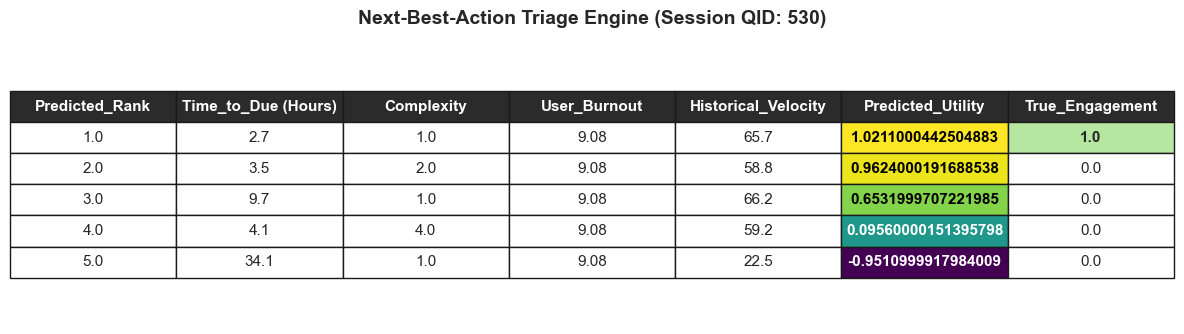

In [13]:
print("[*] Simulating Node.js API Prioritization Request...")
np.random.seed(42)
sample_session_id = np.random.choice(qid_test.unique())

session_mask = (qid_test == sample_session_id)
X_session = X_test[session_mask].copy()
y_session_true = y_test[session_mask].copy()
predicted_utility = tuned_champion.predict(X_session)

df_qualitative = X_session.copy()
df_qualitative['Predicted_Utility'] = predicted_utility
df_qualitative['True_Engagement'] = y_session_true.values

df_sorted = df_qualitative.sort_values(by='Predicted_Utility', ascending=False).reset_index(drop=True)

df_sorted['Predicted_Rank'] = df_sorted.index + 1
df_sorted['Time_to_Due (Hours)'] = df_sorted['time_to_due_date'].round(1)
df_sorted['Complexity'] = df_sorted['dynamic_difficulty']
df_sorted['User_Burnout'] = df_sorted['user_burnout_index'].round(2)
df_sorted['Historical_Velocity'] = df_sorted['historical_velocity_for_tag'].round(1)
df_sorted['Predicted_Utility'] = df_sorted['Predicted_Utility'].round(4)

display_cols = [
    'Predicted_Rank', 
    'Time_to_Due (Hours)', 
    'Complexity', 
    'User_Burnout', 
    'Historical_Velocity', 
    'Predicted_Utility', 
    'True_Engagement'
]

top_5_df = df_sorted[display_cols].head(5)

print(f"\n[+] Triage Complete for Session QID: {sample_session_id}")
print("[+] Rendering Top 5 Recommended Actions via Native Matplotlib...")

plot_triage(top_5_df, sample_session_id)

In [14]:
import pickle
with open("output\\recommender_engine.pkl", 'wb') as f:
    pickle.dump(tuned_champion, f)

print("===================================================================")
print(" ENGINE 3 STATE SEALED & SERIALIZED")
print("===================================================================")
print(f"Object:      XGBRanker (Pairwise LTR)")
print(f"Saved to:    output")
print("===================================================================")

 ENGINE 3 STATE SEALED & SERIALIZED
Object:      XGBRanker (Pairwise LTR)
Saved to:    output
